In [26]:
import numpy as np
from scipy import signal
from week4solution import *
import matplotlib.pyplot as plt
import time

In [27]:
#This is just to set the default figure parameters to smarter values for me, you can change them or remove/not run this cell
import matplotlib
matplotlib.rcParams.update({'font.size': 16})
matplotlib.rcParams['figure.figsize'] = (14.0, 4.0)


## First do the convolution of the two vectors

## Make sure you flip them the right way!!

    [1,-2,3,0]  =0
 [4,2,0]

    [1,-2,3,0] = -2*0+2*1=2
  [4,2,0]
ell
  etc 

  

In [28]:
a=np.array([1,-2,3,0])
na=np.size(a)
b=np.array([0,2,4])
nb=np.size(b)
c=np.zeros(na+nb-1)  

Here we have to flip the second vector and then move it along the first vector.  To make this easy, I setup the code to make it easy to see what is changing at each line.  This will help in the setting up the loops for the convolution later.  Notice that the $a$ indices essentially do not change, but the $b$ indices do change as we go through the loop.  We would get the same answer if we switch a and b.

In [29]:
c[0]=a[0]*b[0]
c[1]=a[0]*b[1]+a[1]*b[0]
c[2]=a[0]*b[2]+a[1]*b[1]+a[2]*b[0]
c[3]=          a[1]*b[2]+a[2]*b[1]+a[3]*b[0]
c[4]=                    a[2]*b[2]+a[3]*b[1]
c[5]=                              a[3]*b[2]

Check that we got it right

In [30]:
c2=np.convolve(a,b)
print(c,c2)

[ 0.  2.  0. -2. 12.  0.] [ 0  2  0 -2 12  0]


Check that $a\ast b=b\ast a$, which it clearly is, demonstrating that the convolution commutes.

In [31]:
c1=myconv(a,b)
c3=myconv(b,a)
print(c1,c3)

[ 0.  2.  0. -2. 12.  0.] [ 0.  2.  0. -2. 12.  0.]


In [32]:
def myconv(a,b):
# return the convolution of the signals a and b

    na=np.size(a)
    nb=np.size(b)
    c=np.zeros([na+nb-1])
    nc=np.size(c)
    
    for ic in range(nc):
        for isum in range(max(na,nb)):
            if np.abs(isum) <na and np.abs(ic-isum)<nb and ic-isum>=0:
                c[ic]=c[ic]+a[isum]*b[ic-isum]
               # c[ic]=c[ic]+a[isum]*b[ic-isum]
                #print(ic,isum,ic-isum) I use this for debugging and didn't remove it because you never know when you will have to debug again!
                 
    return c



Now do the convolution of the next set of signals.  We see that the filter flips the data by $180^\circ$ because of the -1.  It also doubles the amplitude because there are two -1 elements.  If we remove one of those then we will have an amplitude 1 signal still.  This is because it adds two adjacent values if you change the number of ones you will see a change in the amplitude of the resulting signal.

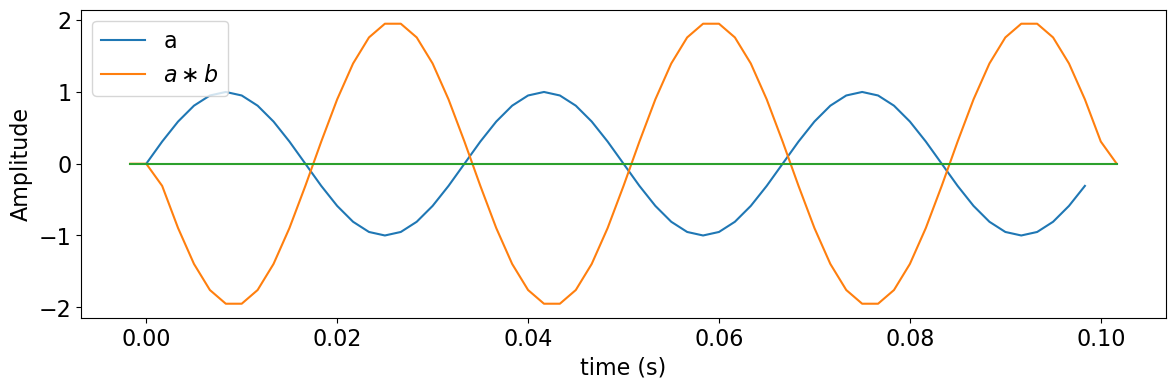

In [43]:
a,t=mysin(30,600)
#b=np.array([1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])
b=np.array([0,-1,-1,0])
nb=np.size(b)
c=myconv(a,b)
dt=t[2]-t[1]
nt=np.size(t)
t2=np.arange(-int(nb/2)+1,nt+int(nb/2))*dt
plt.plot(t,a,label='a')
plt.plot(t2,c,label=r'$a\ast b$')
plt.plot(t2,np.zeros_like(t2))
plt.xlabel('time (s)')
plt.ylabel('Amplitude')
plt.legend()

## Correlation

First we will test with the vectors used in the lecture:

In [34]:
a=np.array([1,0,0])
b=np.array([2,3,4])
c=mycorr(a,b)
c2=np.correlate(b,a,mode='Full')
print(c)
print(c2)

[0. 0. 2. 3. 4.]
[0 0 2 3 4]


In [35]:
def mycorr(f,g):
# return the correlation of the signals f and g
    nf=np.size(f)
    ng=np.size(g)
    h=np.zeros([nf+ng-1])
    nh=np.size(h)
    index = 0    # index is 0 to len(h) to calculate h
    for ih in range(-(nf-1),ng): # ih is lag index
        for ind in range(max(nf,ng)):
            if np.abs(ih+ind) <ng and ih+ind>-1 and ind <nf  : # if 1) g index is less than len(g)
                                                               # if 2) g index is positive
                                                               # if 3) f index is less than len(f)
                val = f[ind]*g[ih+ind]
                h[index]=h[index]+val
        index = index + 1
    return h


In [36]:
def mycorr(f,g):
# return the correlation of the signals f and g
    nf=np.size(f)
    ng=np.size(g)
    h=np.zeros([nf+ng-1])
    nh=np.size(h)
    index = 0    # index is 0 to len(h) to calculate h
    for ih in range(-(nf-1),ng): # ih is lag index
        #print('ih = ' + str(ih))
        for ind in range(max(nf,ng)):
            #print('ind = ' + str(ind))
            if np.abs(ih+ind) <ng and ih+ind>-1 and ind <nf  :
                h[index]= h[index] + f[ind]*g[ih+ind]
                #print('ind = ' + str(ind))
                #print('ih+ind = ' + str(ih+ind))
        #print('index = ' + str(index))
        index = index + 1
        return h

In [37]:
a=np.array([1,2,3])
b=np.array([4,5,6,7])
#c4=mycorr2(a,b)
#print(c4)
c=mycorr(a,b)
print(c)
c2=mycorr_old(a,b)
print(c,c2)
c3=np.correlate(b,a,mode='full')
print(c,c2,c3)

[12.  0.  0.  0.  0.  0.]
[12.  0.  0.  0.  0.  0.] [12. 23. 32. 38. 20.  7.]
[12.  0.  0.  0.  0.  0.] [12. 23. 32. 38. 20.  7.] [12 23 32 38 20  7]


### Now we setup the signals that we are going to use to find the shift between them.

First we load the data, which is done for you, but the data must be in the same directory as this code!

Text(0.5, 1.0, 'Initial Signals')

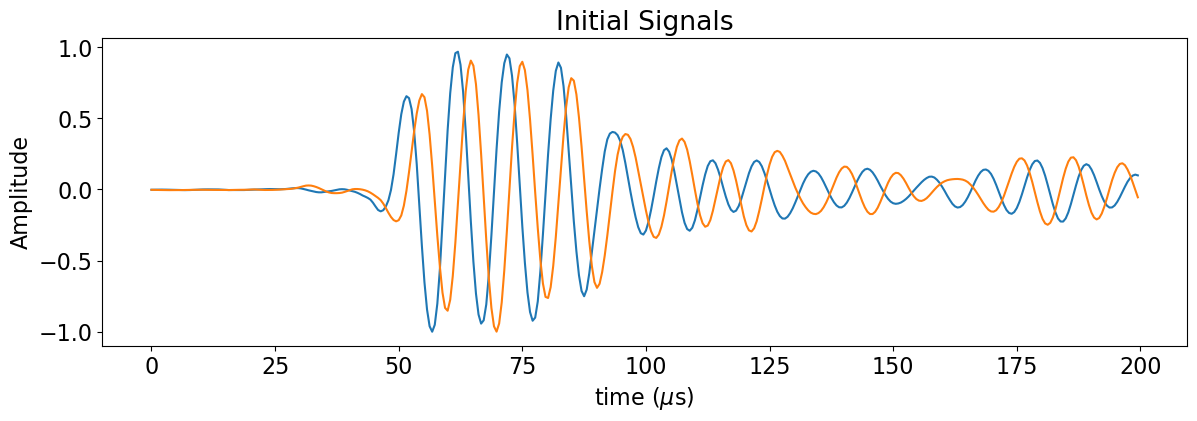

In [38]:
dat=np.loadtxt('Sigs_for_shift.txt')
t=dat[0]
sig1=dat[1]
sig2=dat[2]
plt.plot(t,sig1,t,sig2)
plt.xlabel(r'time ($\mu$s)')
plt.ylabel('Amplitude')
plt.title('Initial Signals')

Note that the correlation is not instantaneous, so I suggest putting it in its own cell so you only have to run it once!  Then we plot the correlation and look for the peak.  You can just zoom in and read the peak location off of the graph or find the location of the maximum of the function.

In [39]:
corr_sig1_sig2=mycorr(sig1,sig2)

2.603999999999992


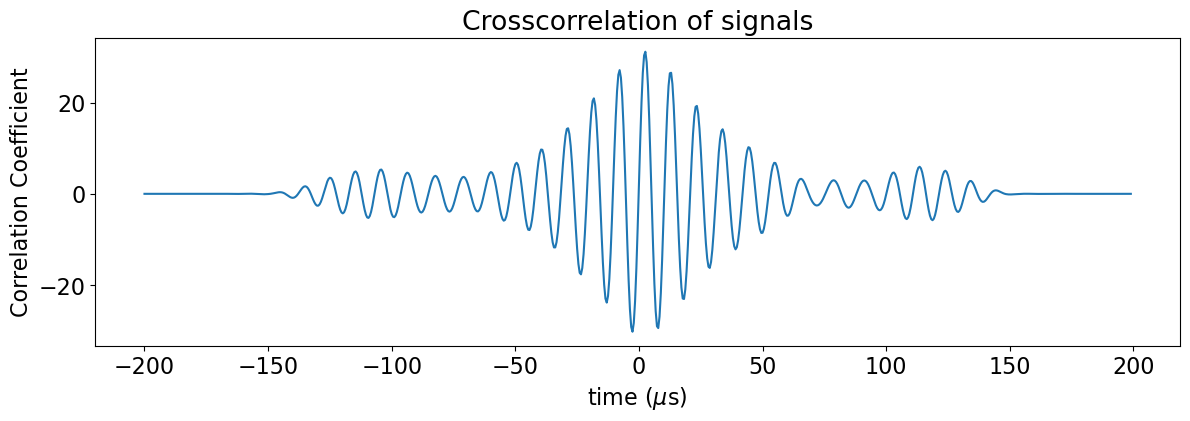

In [15]:
nt=np.size(t)
dt=t[2]-t[1]
t_corr=np.arange(-nt,nt-1)*dt
plt.plot(t_corr,corr_sig1_sig2)
plt.xlabel(r'time ($\mu$s)')
plt.ylabel('Correlation Coefficient')
plt.title('Crosscorrelation of signals')

#zoom in and you will see that the peak is at about 2.5 $\mu$s
#plt.xlim([-10,10])
#or just find the location of the max, which is 2.6~$\mu$s
maxloc=np.argmax(np.abs(corr_sig1_sig2))
shift=t_corr[maxloc]
print(shift)

We can check that we got it right by shifting one signal and then comparing

5 2.6040999999999994


Text(0.5, 1.0, 'Initial Signals')

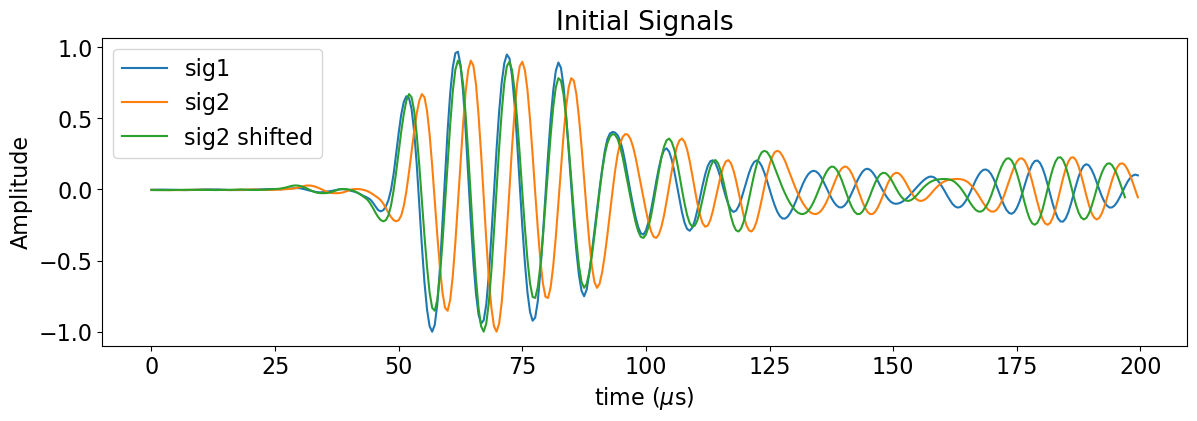

In [16]:
plt.plot(t,sig1,label='sig1')
plt.plot(t,sig2,label='sig2')
tloc=np.argmin(np.abs(t-shift))
print(tloc,t[tloc])
plt.plot(t[:-tloc],sig2[tloc:],label='sig2 shifted')
plt.legend()
plt.xlabel(r'time ($\mu$s)')
plt.ylabel('Amplitude')
plt.title('Initial Signals')

### Now we convolve and correlate with the reflectivity signal

/var/folders/st/hcync8bj1yn1j3bx3sh8m5j40000gn/T/ipykernel_2416/320001810.py:5: DeprecationWarning: scipy.signal.ricker is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  wavelet = signal.ricker(30, 3)


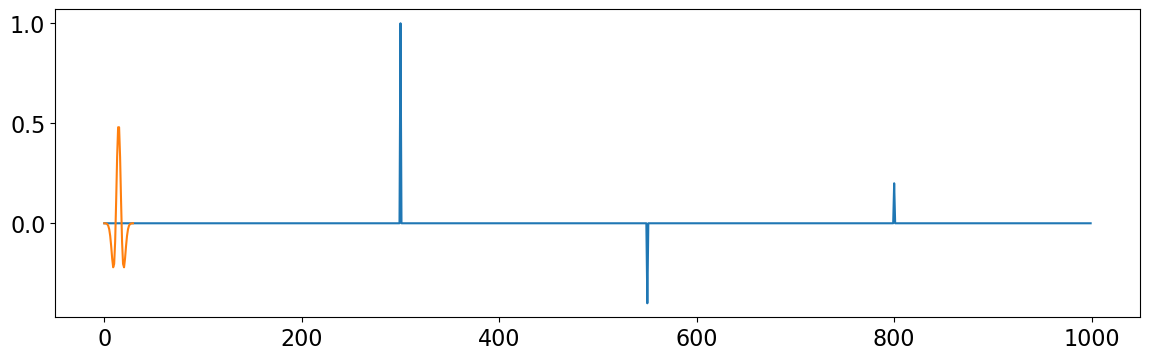

In [17]:
r=np.zeros([1000])
r[300]=1
r[800]=.2
r[550]=-.4
wavelet = signal.ricker(30, 3)
plt.plot(r)
plt.plot(wavelet)

In [18]:
c1=myconv(r,wavelet)
c2=mycorr(r,wavelet)


Text(0.5, 1.0, 'synthetic seismogram')

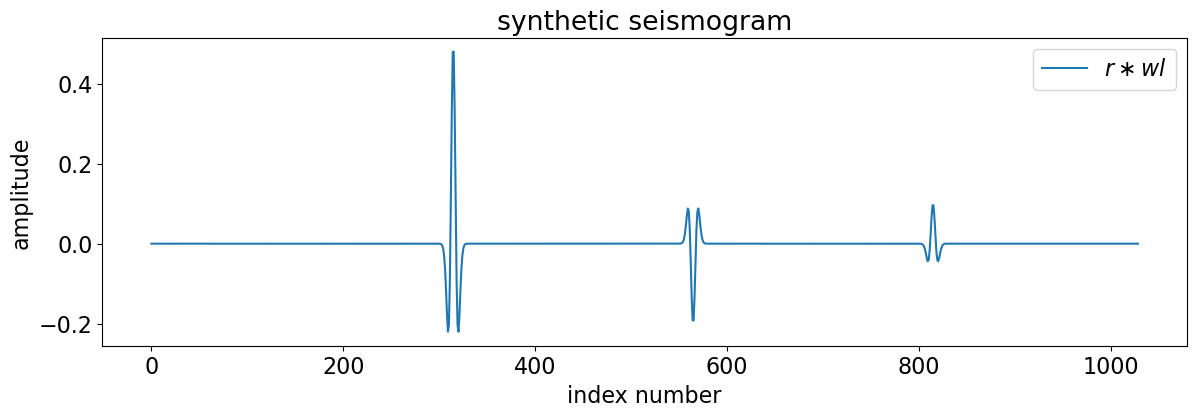

In [19]:
plt.plot(c1,label=r'$r\ast wl$')
#plt.plot(c2,label=r'$r\star wl$')
plt.legend()
plt.xlabel('index number')
plt.ylabel('amplitude')
plt.title('synthetic seismogram')

We see that the correlated version is backward!  So if we flip the correlated signal then they will overlay.  Note that to get a true seismogram we would also have to scale the x-axis to be a time.  This is done by converting the depth (where the reflectivity is given) to time, or by just using the reflectivity in time if that is how it is given.  When you do this you also have to be careful that you take into account the shift of the wavelet from time zero.

Text(0.5, 1.0, 'synthetic seismogram')

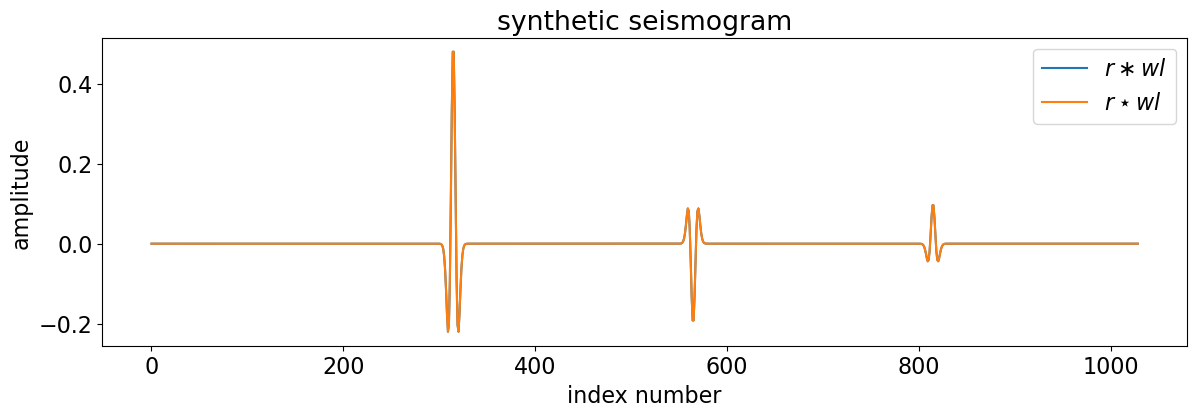

In [20]:
plt.plot(c1,label=r'$r\ast wl$')
plt.plot(c2[::-1],label=r'$r\star wl$')
plt.legend()
plt.xlabel('index number')
plt.ylabel('amplitude')
plt.title('synthetic seismogram')

If you evaluate this cell it will give you some useful information about np.correlate.  You can do this for any program!

In [16]:
np.correlate?

In [12]:
c=np.correlate([2,3,4],[1,0,0],mode='full')

In [13]:
print(c)

[0 0 2 3 4]
